# STEP 1: Define the Vocabulary

In [336]:
import numpy as np
import pandas as pd

np.set_printoptions(precision=4, suppress=True)

sentence = "I like orange juice and eat eggs daily"
tokens = sentence.split()

vocabulary = list(dict.fromkeys(tokens))
V = len(vocabulary)
N = 3

word_to_index = {word: i for i, word in enumerate(vocabulary)}
index_to_word = {i: word for i, word in enumerate(vocabulary)}

print("Vocabulary:", vocabulary)
print("V =", V, "N =", N)

Vocabulary: ['I', 'like', 'orange', 'juice', 'and', 'eat', 'eggs', 'daily']
V = 8 N = 3


# STEP 2: Generate Skip-Gram Training Data

In [337]:
def get_context(tokens, index, window_size=2):
    start = max(0, index - window_size)
    end = min(len(tokens), index + window_size + 1)
    return [tokens[i] for i in range(start, end) if i != index]

training_data = []

for i, word in enumerate(tokens):
    context_words = get_context(tokens, i)
    for context_word in context_words:
        training_data.append((word, context_word))

print("Training pairs:")
for pair in training_data:
    print(pair)

Training pairs:
('I', 'like')
('I', 'orange')
('like', 'I')
('like', 'orange')
('like', 'juice')
('orange', 'I')
('orange', 'like')
('orange', 'juice')
('orange', 'and')
('juice', 'like')
('juice', 'orange')
('juice', 'and')
('juice', 'eat')
('and', 'orange')
('and', 'juice')
('and', 'eat')
('and', 'eggs')
('eat', 'juice')
('eat', 'and')
('eat', 'eggs')
('eat', 'daily')
('eggs', 'and')
('eggs', 'eat')
('eggs', 'daily')
('daily', 'eat')
('daily', 'eggs')


# STEP 3: Initialise Weights

In [338]:
global W, W_prime
W = np.random.randn(V, N) * 0.01
W_prime = np.random.randn(N, V) * 0.01
print("W:\n", W)
print()
print("W_prime:\n", W_prime)

W:
 [[-0.0233  0.0168  0.0028]
 [ 0.0092  0.0027 -0.0064]
 [ 0.0006  0.0048  0.0024]
 [ 0.0245  0.0006  0.0151]
 [ 0.0085 -0.0056  0.0039]
 [ 0.0087  0.0052  0.0011]
 [ 0.0039  0.0037 -0.009 ]
 [-0.0006 -0.0056  0.0032]]

W_prime:
 [[ 0.0093  0.0083 -0.0011  0.0123  0.0036  0.008   0.0184  0.0088]
 [-0.0079 -0.0084 -0.0223 -0.006  -0.0142  0.0032  0.0114  0.0018]
 [-0.0021  0.0047  0.0078  0.0077 -0.0003  0.0035 -0.0047  0.0009]]


# STEP 4: Select one Skip-Gram training pair

We take one target word and the context words in window sized at 2 from the generated training data.

In [339]:
target_word = "juice"

context_words = get_context(tokens, tokens.index(target_word), window_size=2)

print("Target word:", target_word)
print("Actual context words:", context_words)

Target word: juice
Actual context words: ['like', 'orange', 'and', 'eat']


# STEP 5: One-hot encode the target word

In Skip-Gram, the input is a single target word.

In [340]:
def one_hot(word):
    vec = np.zeros(V)
    vec[word_to_index[word]] = 1
    return vec

x = one_hot(target_word)

print("STEP 5: One-Hot Vector for Target Word")
print(f"{target_word:>7} -> {x}")

STEP 5: One-Hot Vector for Target Word
  juice -> [0. 0. 0. 1. 0. 0. 0. 0.]


# STEP 6: Project the target word to the hidden layer

one-hot(target) @ W gives the embedding of the target word.


In [341]:
h = x @ W

print("STEP 6: Hidden Layer Representation")
print("Hidden vector h =", h)
print("Shape of h =", h.shape)

STEP 6: Hidden Layer Representation
Hidden vector h = [0.0245 0.0006 0.0151]
Shape of h = (3,)


# STEP 7: Compute output scores

h @ W_prime gives one score for every word in the vocabulary.

In [342]:
u = h @ W_prime

print("STEP 7: Output Scores (Before Softmax)")
score_df = pd.DataFrame({
    "Word": vocabulary,
    "Score": u
})
print(score_df)

STEP 7: Output Scores (Before Softmax)
     Word     Score
0       I  0.000191
1    like  0.000269
2  orange  0.000076
3   juice  0.000414
4     and  0.000076
5     eat  0.000251
6    eggs  0.000388
7   daily  0.000231


# STEP 8: Apply softmax to convert scores into probabilities

In [343]:
def softmax(x):
    shifted = x - np.max(x)      # numerical stability
    exp_x = np.exp(shifted)
    return exp_x / np.sum(exp_x)

y_pred = softmax(u)

print("STEP 8: Softmax Output Probabilities")
prob_df = pd.DataFrame({
    "Word": vocabulary,
    "Probability": y_pred
}).sort_values(by="Probability", ascending=False).reset_index(drop=True)
print(prob_df)

STEP 8: Softmax Output Probabilities
     Word  Probability
0   juice     0.125022
1    eggs     0.125019
2    like     0.125004
3     eat     0.125002
4   daily     0.124999
5       I     0.124994
6     and     0.124980
7  orange     0.124980


# STEP 9: Show the top-k predicted words

In a single forward pass, Skip-Gram gives a probability distribution over the whole vocabulary. The actual context words should ideally receive high probabilities.

In [344]:
k = len(context_words)

print(f"\nSTEP 9: Top {k} Predicted Words")
top_k_df = prob_df.head(k).copy()
print(top_k_df)


STEP 9: Top 4 Predicted Words
    Word  Probability
0  juice     0.125022
1   eggs     0.125019
2   like     0.125004
3    eat     0.125002


# STEP 10: Compare predicted top words with actual context words

In [345]:
predicted_top_words = top_k_df["Word"].tolist()

print("\nSTEP 10: Compare with Actual Context Words")
print("Target word           =", target_word)
print("Actual context words  =", context_words)
print("Top predicted words   =", predicted_top_words)


STEP 10: Compare with Actual Context Words
Target word           = juice
Actual context words  = ['like', 'orange', 'and', 'eat']
Top predicted words   = ['juice', 'eggs', 'like', 'eat']


# STEP 11: Mark which vocabulary words are actual context words

In [346]:
comparison_df = pd.DataFrame({
    "Word": vocabulary,
    "Probability": y_pred,
    "Is_Actual_Context": [word in context_words for word in vocabulary]
}).sort_values(by="Probability", ascending=False).reset_index(drop=True)

print("\nSTEP 11: Vocabulary Probabilities with Context Marker")
print(comparison_df)


STEP 11: Vocabulary Probabilities with Context Marker
     Word  Probability  Is_Actual_Context
0   juice     0.125022              False
1    eggs     0.125019              False
2    like     0.125004               True
3     eat     0.125002               True
4   daily     0.124999              False
5       I     0.124994              False
6     and     0.124980               True
7  orange     0.124980               True


# STEP 12: Probability mass on actual context

In [347]:
context_prob_sum = sum([y_pred[word_to_index[w]] for w in context_words])

print("\nSTEP 12: Total Probability Assigned to Actual Context Words")
print("Sum of probabilities for context words =", context_prob_sum)


STEP 12: Total Probability Assigned to Actual Context Words
Sum of probabilities for context words = 0.49996550637748627


# Neural Network Visualisation

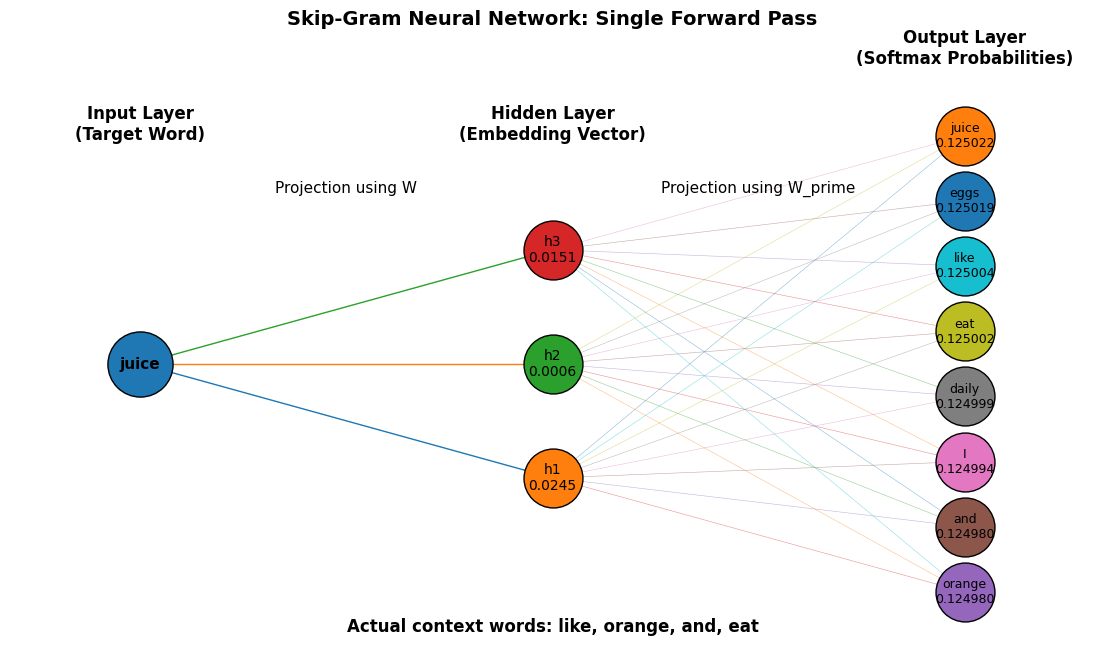

In [348]:
import matplotlib.pyplot as plt

# STEP 13: Visualise the Skip-Gram neural network for the single forward pass

fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.08)
ax.axis("off")

# ------------------------------------------------------------
# Node positions
# ------------------------------------------------------------
input_x = 0.12
hidden_x = 0.50
output_x = 0.88

input_y = 0.50

hidden_ys = np.linspace(0.3, 0.7, N)
output_ys = np.linspace(0.1, 0.9, V)

# ------------------------------------------------------------
# Draw input node
# ------------------------------------------------------------
ax.scatter(input_x, input_y, s=2200, edgecolors="black", zorder=3)
ax.text(input_x, input_y, target_word, ha="center", va="center", fontsize=11, weight="bold")
ax.text(input_x, 0.92, "Input Layer\n(Target Word)", ha="center", va="center", fontsize=12, weight="bold")

# ------------------------------------------------------------
# Draw hidden layer nodes
# ------------------------------------------------------------
for i, y in enumerate(hidden_ys):
    ax.scatter(hidden_x, y, s=1800, edgecolors="black", zorder=3)
    ax.text(hidden_x, y, f"h{i+1}\n{h[i]:.4f}", ha="center", va="center", fontsize=10)

ax.text(hidden_x, 0.92, "Hidden Layer\n(Embedding Vector)", ha="center", va="center", fontsize=12, weight="bold")

# ------------------------------------------------------------
# Draw output layer nodes
# ------------------------------------------------------------
sorted_indices = np.argsort(y_pred)

sorted_words = [vocabulary[i] for i in sorted_indices]
sorted_probs = [y_pred[i] for i in sorted_indices]

for word, prob, y in zip(sorted_words, sorted_probs, output_ys):
    ax.scatter(output_x, y, s=1800, edgecolors="black", zorder=3)
    ax.text(output_x, y, f"{word}\n{prob:.6f}", ha="center", va="center", fontsize=9)

ax.text(output_x, 1.02, "Output Layer\n(Softmax Probabilities)",
        ha="center", va="bottom", fontsize=12, weight="bold")

# ------------------------------------------------------------
# Draw connections: input -> hidden
# ------------------------------------------------------------
for y in hidden_ys:
    ax.plot([input_x, hidden_x], [input_y, y], linewidth=1)

# ------------------------------------------------------------
# Draw connections: hidden -> output
# ------------------------------------------------------------
for hy in hidden_ys:
    for oy in output_ys:
        ax.plot([hidden_x, output_x], [hy, oy], linewidth=0.4, alpha=0.5)

# ------------------------------------------------------------
# Add annotations
# ------------------------------------------------------------
ax.text(0.31, 0.80, "Projection using W", fontsize=11, ha="center")
ax.text(0.69, 0.80, "Projection using W_prime", fontsize=11, ha="center")

actual_context_text = ", ".join(context_words)
ax.text(0.5, 0.03, f"Actual context words: {actual_context_text}", ha="center", fontsize=12, weight="bold")

plt.title("Skip-Gram Neural Network: Single Forward Pass", fontsize=14, weight="bold")
plt.show()